In [ ]:
#packages
import numpy as np
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import (load_data, confusion_table)
from ISLP.models import (ModelSpec as MS, summarize, contrast)
from sklearn.model_selection import train_test_split 
# from sklearn.naive_bayes import GaussianNB
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, roc_auc_score
# for Gradient Boosting 
from sklearn.ensemble import GradientBoostingRegressor as GBR
from sklearn.model_selection import GridSearchCV


roc_curve_est = RocCurveDisplay.from_estimator 
roc_curve_pred = RocCurveDisplay.from_predictions 

### This project will use the [Sleep, Health, and Lifestyle dataset](https://www.kaggle.com/datasets/ayeshaimran1619/sleep-and-lifestyle-study) from Kaggle.

In [19]:
sleep = pd.read_csv('data/Sleep_health_and_lifestyle_dataset.csv')
sleep.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


### Data Preprocessing

#### - Split blood pressure into systolic (artery pressure during contractions) and diastolic (pressure when heart relaxes between beats)
#### - Use one-hot encoding for categorical variables

In [20]:
sleep[['Systolic BP', 'Diastolic BP']] = sleep['Blood Pressure'].str.split('/', expand = True).astype(int)

sleep['BMI Category'] = sleep['BMI Category'].replace('Normal Weight', 'Normal')

sleep['Has Disorder'] = sleep['Sleep Disorder'].notna().astype(int)

sleep = sleep.drop(['Blood Pressure', 'Sleep Disorder', 'Person ID'], axis=1)

categorical_columns = ['Gender', 'Occupation', 'BMI Category']
sleep = pd.get_dummies(sleep, columns = categorical_columns, drop_first = True, dtype = int)

sleep

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP,Has Disorder,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Obese,BMI Category_Overweight
0,27,6.1,6,42,6,77,4200,126,83,0,...,0,0,0,0,0,0,1,0,0,1
1,28,6.2,6,60,8,75,10000,125,80,0,...,0,0,0,0,0,0,0,0,0,0
2,28,6.2,6,60,8,75,10000,125,80,0,...,0,0,0,0,0,0,0,0,0,0
3,28,5.9,4,30,8,85,3000,140,90,1,...,0,0,0,1,0,0,0,0,1,0
4,28,5.9,4,30,8,85,3000,140,90,1,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,59,8.1,9,75,3,68,7000,140,95,1,...,0,0,1,0,0,0,0,0,0,1
370,59,8.0,9,75,3,68,7000,140,95,1,...,0,0,1,0,0,0,0,0,0,1
371,59,8.1,9,75,3,68,7000,140,95,1,...,0,0,1,0,0,0,0,0,0,1
372,59,8.1,9,75,3,68,7000,140,95,1,...,0,0,1,0,0,0,0,0,0,1


### To begin, we will use Logistic Regression to determine the presence of a sleep disorder rather than a specific diagnosis.

In [21]:
# isolate binary sleep disorders column (target variable)
X = sleep.drop('Has Disorder', axis=1)
y = sleep['Has Disorder']

x_train, x_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=314159,
                                                    test_size=0.33,
                                                    shuffle=True)

# add dummy variables 
x_train['intercept'] = np.ones(x_train.shape[0])
x_test['intercept'] = np.ones(x_test.shape[0])

### Scale features using min-max regularization

In [22]:
needs_scaled = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']

for col in needs_scaled:
    col_min = x_train[col].min()
    col_max = x_train[col].max()

    x_train[col] = (x_train[col] - col_min) / (col_max - col_min)
    
    x_test[col] = (x_test[col] - col_min) / (col_max - col_min)

In [23]:
initial_glm = sm.GLM(y_train,
             x_train,
             family=sm.families.Binomial())

# fit model
initial_results = initial_glm.fit()

# analyze model
summarize(initial_results)

,coef,std err,z,P>|z|
Age,3.828600e+00,6.592000e+00,0.581,0.561
Sleep Duration,4.850000e-02,5.357000e+00,0.009,0.993
Quality of Sleep,-1.326800e+01,1.022800e+01,-1.297,0.195
Physical Activity Level,-3.107100e+00,2.765000e+00,-1.124,0.261
Stress Level,-4.905300e+00,6.147000e+00,-0.798,0.425
Heart Rate,-1.540500e+00,9.693000e+00,-0.159,0.874
Daily Steps,-2.414000e-01,4.537000e+00,-0.053,0.958
Systolic BP,-2.430800e+00,1.174700e+01,-0.207,0.836
Diastolic BP,2.012820e+01,1.391600e+01,1.446,0.148
Gender_Male,1.365000e+00,2.637000e+00,0.518,0.605


### Since the above model will likely be overfit, we can try a subset of features 

In [24]:
sleep.corr()['Has Disorder'].sort_values()

Sleep Duration                    -0.338622
Quality of Sleep                  -0.310984
Occupation_Doctor                 -0.310362
Occupation_Engineer               -0.291633
Gender_Male                       -0.285824
Occupation_Lawyer                 -0.237076
Occupation_Manager                -0.043560
Occupation_Software Engineer      -0.034707
Daily Steps                       -0.026575
Occupation_Scientist               0.018059
Physical Activity Level            0.069787
Occupation_Sales Representative    0.087156
Stress Level                       0.181685
BMI Category_Obese                 0.197018
Occupation_Teacher                 0.253291
Occupation_Salesperson             0.324787
Heart Rate                         0.330254
Age                                0.432007
Occupation_Nurse                   0.462127
Systolic BP                        0.692480
Diastolic BP                       0.705025
BMI Category_Overweight            0.751018
Has Disorder                    

### Now we can train a logistic regression model using features with strong correlations.

In [25]:
variables_to_use = ['BMI Category_Overweight', 'Systolic BP', 'Occupation_Nurse', 'Age', 'Heart Rate', 'Sleep Duration', 'Quality of Sleep']

glm = sm.GLM(y_train, x_train[variables_to_use], family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
BMI Category_Overweight,1.0251,0.792,1.294,0.196
Systolic BP,7.2324,1.877,3.853,0.000
Occupation_Nurse,-0.4083,0.770,-0.531,0.596
Age,2.9209,1.883,1.551,0.121
Heart Rate,-1.9399,1.170,-1.657,0.097
Sleep Duration,2.6615,1.880,1.416,0.157
Quality of Sleep,-10.1262,2.246,-4.508,0.000


### Once the model is trained, we can calculate the predicted probablilities and generate a confusion table for the training set

In [26]:
def predict(X, model):
    # the built-in get_prediction tool returns an array, so we need to convert to a dataframe
    predictions_df = pd.DataFrame(model.get_prediction(X).predicted, columns=['y_hat'], index=X.index)
    return predictions_df['y_hat']

probs_train=predict(x_train[variables_to_use],results)
probs_test=predict(x_test[variables_to_use],results)

predictions_train = np.array([True]*len(y_train))
predictions_train[probs_train<0.5] = False

predictions_test = np.array([True]*len(y_test))
predictions_test[probs_test<0.5] = False

train_table = confusion_table(predictions_train, y_train)
train_table


Truth,0,1
Predicted,,
0,139,12
1,6,93


### And the test set

In [27]:
test_table = confusion_table(predictions_test, y_test)
test_table

Truth,0,1
Predicted,,
0,69,3
1,5,47


In [28]:
misclassification_rate = (test_table.loc[1, 0] + test_table.loc[0, 1]) / test_table.values.sum()
print("misclassification rate =", misclassification_rate)

false_positive_rate = test_table.loc[1, 0] / test_table[0].sum()
print("fpr =",false_positive_rate)

false_negative_rate = test_table.loc[0, 1] / test_table[1].sum()
print("fnr =",false_negative_rate)

misclassification rate = 0.06451612903225806
fpr = 0.06756756756756757
fnr = 0.06


### Using logistic regression, we can determine whether an individual has a sleep disorder with a total misclassification rate of 6.4%, a false positive rate of 6.8%, and a false negative rate of 6%.

### Now we can see how the model performs using an ROC curve

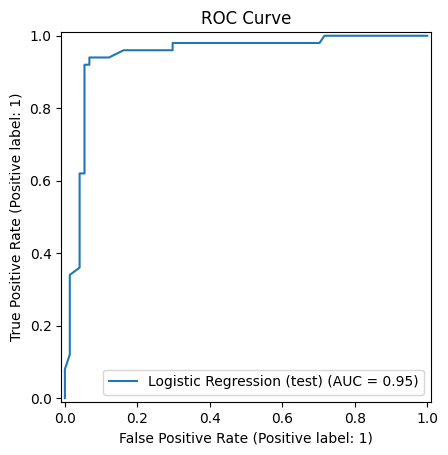

AUC = 0.9451351351351351


In [29]:
roc_curve_pred(y_test, probs_test, name='Logistic Regression (test)')
plt.title('ROC Curve')
plt.show()
print("AUC =", roc_auc_score(y_test, probs_test))

### An area under the curve of 95% indicates that the model is very accurate, since an AUC of 1.0 is perfect and 0.5 means the model is no better than random guessing.

### Now we can define helper functions to find the MSE and the GBM progress


In [30]:
def mse(y, y_hat):
    """
    Calculate the MSE of a model given actual and predicted values
    """
    # calculate the residual error for each individual record
    resid = y - y_hat
    # square the residual (hence "squared error")
    sq_resid = resid**2
    # calculate the sum of squared errors
    SSR = sum(sq_resid)
    # divide by the number of records to get the mean squared error
    MSE = SSR / y.shape[0]
    return MSE
def gbm_progress(model_name, X_test, y_test):
    """
    Plot the 'progress' of a GBM on a test set to assess robustness
    """
    test_error = np.zeros_like(model_name.train_score_)
    for idx, y_ in enumerate(model_name.staged_predict(X_test)):
        test_error[idx] = np.mean((y_test - y_)**2)

    plot_idx = np.arange(model_name.train_score_.shape[0])
    ax = subplots(figsize=(8,8))[1]
    ax.plot(plot_idx,
            model_name.train_score_,
            'b',
            label='Training')
    ax.plot(plot_idx,
            test_error,
            'r',
            label='Test')
    ax.legend()

### Build the BASIC GBM


In [32]:
gbm_basic = GBR(learning_rate=0.1,
               n_estimators=250,
               max_depth=10,
               min_samples_split=2,
               subsample=1,
               random_state=42)

gbm_basic.fit(x_train[variables_to_use], y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",250
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft c

Now make the test mse:


In [33]:
y_hat_basic = gbm_basic.predict(x_test[variables_to_use])

mse_basic = mse(y_test, y_hat_basic)
print('test mse: ',mse_basic)

test mse:  0.06989063861404389


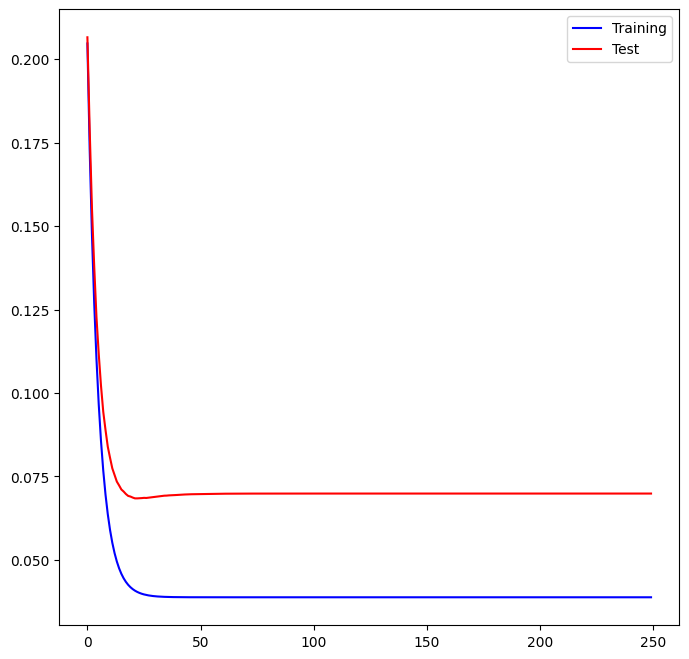

In [34]:
gbm_progress(gbm_basic, x_test[variables_to_use], y_test)

In [ ]:
def get_best_gbm(x, y, save_results=False):
    print("Running GridSearchCV...")

    gbm_cv = GBR(random_state=42)

    param_grid = {
        "n_estimators": [100, 300],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5, 6],
        "min_samples_leaf": [3, 5, 7],  # fixed
        "subsample": [0.7, 0.9]
    }

    grid_search = GridSearchCV(
        estimator=gbm_cv,
        param_grid=param_grid,
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        verbose=3
    )

    grid_search.fit(x, y)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print("\nBest Parameters:", best_params)
    print("Best Score (neg MSE):", grid_search.best_score_)
    if save_results:
        results_df = pd.DataFrame(grid_search.cv_results_)
        results_df.to_csv("gbm_gridsearch_results.csv", index=False)
        print("Saved results to gbm_gridsearch_results.csv")

    return best_model, best_params

In [ ]:
#find the best model
best_model, best_params = get_best_gbm(x_train[variables_to_use], y_train, force_retain=False)

print("Best parameters:")
print(best_params)

TODO:
    
    - maybe print some graphs before creating the model
    
    - random forest and gbm to classify what disorder, if any, someone has